# Modelo final — CatBoost sobre el precio de Airbnb Nueva York

Este notebook entrna los dos modelos elegidos en `Modelado.ipynb` con **todo el train**, lo evalúa **una sola vez** en el test, analiza dónde acierta y dónde falla, lo interpreta y lo guarda para usarlo. 

**Decisiones cerradas :**

- **Modelo:** solo `CatBoost_ajustado`, el de menor RMSE medio de validación en el escenario B (conociendo al anfitrion). No hay
  contrastes en el test; lineal, HGB y la referencia N0.3 se comparan **con la CV** (`outputs/experimentos.csv`).
- **Intervalo:** cuantiles 0,1 y 0,9 de CatBoost con los mismos hiperparámetros, calibrados con **CQR con un solo conjunto de calibración**: se ajustan con el train del fold 0 y se calibran con su validación; esos mismos dos modelos son los cuantiles finales.
- **Interpretación:** SHAP nativo de CatBoost.
- **Guardado:** modelo, cuantiles, correcciones, ficha y `predecir_precio`.

**Regla del test:** se carga **una vez** (sección 4). Nada de lo que salga en él puede cambiar el modelo, los
hiperparámetros ni las variables.

In [1]:
import json
import sys
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from func_modelado import *
from func_final import *

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
RUTA_REGISTRO = OUTPUT_DIR / 'experimentos.csv'

COLOR_BASE, COLOR_SECUNDARIO = '#2a6f97', '#9aa5b1'
MODELO_ELEGIDO = 'CatBoost_ajustado'
pd.set_option('display.max_columns', 40)

## 1. CARGA DEL TRAIN Y CONFIGURACIÓN DEL MODELO ELEGIDO

Los hiperparámetros y las variables se leen del registro de experimentos que hemos ido guardadndo a medida que los entrenabamos. Se comprueba también el MD5 (huella digital de 32 caracteres) del test **sin cargarlo**: si no coincide con el de `particion.json`, se para.

In [20]:
train, bloques = cargar_modelado('train')
HIPERPARAMETROS = hiperparametros_registrados(MODELO_ELEGIDO, RUTA_REGISTRO)
COLUMNAS = columnas_registradas(MODELO_ELEGIDO, RUTA_REGISTRO)
assert set(COLUMNAS) == set(columnas_de(bloques, BLOQUES_ESCENARIO['B'])), 'Las variables del registro no son las del escenario B'

particion = json.loads((DATA_DIR / 'particion' / 'particion.json').read_text(encoding='utf-8'))
md5_test = md5_fichero(DATA_DIR / 'particion' / 'listings_test.csv')
assert md5_test == particion['md5']['test'], 'El test no coincide con la particion guardada: se para'

print(f"Train de modelado: {len(train):,} anuncios de {train[COL_GRUPO].nunique():,} anfitriones | {len(COLUMNAS)} variables")
print(f"MD5 del test (sin cargarlo): {md5_test} -> coincide con particion.json")
display(pd.Series(HIPERPARAMETROS, name='valor').to_frame().T)

folds = cargar_folds(train, OUTPUT_DIR / 'folds_cv.csv', 3)
FOLDS_MODELOS = [f for f in folds if f.repeticion == 0]
cv_elegido = leer_experimento(MODELO_ELEGIDO, RUTA_REGISTRO, FOLDS_MODELOS)
METRICAS_CV = {c: float(cv_elegido[c].mean()) for c in
               ['rmse_log_val', 'mae_log_val', 'r2_log_val', 'mae_usd_val', 'medae_usd_val', 'mape_val']}
METRICAS_CV_SD = {c: float(cv_elegido[c].std()) for c in METRICAS_CV}
display(pd.DataFrame({'media_cv': METRICAS_CV, 'sd_folds': METRICAS_CV_SD}).round(4))

Train de modelado: 29,538 anuncios de 21,368 anfitriones | 79 variables
MD5 del test (sin cargarlo): 6efbad2d0dd977cb41d7feb0ee114f38 -> coincide con particion.json


,bagging_temperature,depth,early_stopping_rounds,iterations,l2_leaf_reg,learning_rate,random_state,random_strength,task_type,validacion_fraccion
valor,0.618386,7,None,1890,28.336828,0.058586,42,5.246635,CPU,0.1


,media_cv,sd_folds
rmse_log_val,0.4160,0.0071
mae_log_val,0.3051,0.0047
r2_log_val,0.6578,0.0087
mae_usd_val,47.6384,2.5596
medae_usd_val,21.5814,0.3191
mape_val,0.3142,0.0083


### Comparación en CV (sin test)

Solo vamos a entrenar al elegido ya que va a ser el que obtendra un mejor valor. Cuánto mejora sobre el lineal, sobre HGB y sobre la referencia ingenua se
cuenta con los 5 folds guardados, que son los mismos para todos (comparación pareada).

In [3]:
registro = pd.read_csv(RUTA_REGISTRO)
registro = registro[(registro['escenario'] == 'B') & (registro['repeticion'] == 0)]
mejor_lineal = registro[registro['experimento'].str.startswith(('L4_', 'L5_'))].groupby('experimento')[
    'rmse_log_val'].mean().idxmin()
COMPARADOS = {'CatBoost (elegido)': MODELO_ELEGIDO, 'HGB ajustado': 'HGB_ajustado', 'RF ajustado': 'RF_ajustado',
              f'Lineal ({mejor_lineal})': mejor_lineal, 'Referencia N0.3': 'N0.3_mediana_room_type_capacidad'}
por_fold = registro[registro['experimento'].isin(COMPARADOS.values())].pivot(
    index='fold', columns='experimento', values='rmse_log_val')
filas = []
for etiqueta, nombre in COMPARADOS.items():
    dif = por_fold[nombre] - por_fold[MODELO_ELEGIDO]
    filas.append({'modelo': etiqueta, 'rmse_log_cv': por_fold[nombre].mean(), 'sd_folds': por_fold[nombre].std(),
                  'dif_vs_catboost': dif.mean(), 'folds_peor_que_catboost': f'{(dif > 0).sum()}/{len(dif)}'})
tabla_cv = pd.DataFrame(filas).set_index('modelo')
display(tabla_cv.round(4))

,rmse_log_cv,sd_folds,dif_vs_catboost,folds_peor_que_catboost
modelo,,,,
CatBoost (elegido),0.4160,0.0071,0.0000,0/5
HGB ajustado,0.4191,0.0099,0.0031,5/5
RF ajustado,0.4278,0.0119,0.0118,5/5
Lineal (L5_ElasticNet_alpha_0.00032),0.4329,0.0086,0.0169,5/5
Referencia N0.3,0.5349,0.0093,0.1189,5/5


## 2. REENTRENAMIENTO CON TODO EL TRAIN

Entrenamos nuestro model CatBoost sobre todos los anuncios del train (RMSE en log). El RMSE en train debe quedar por debajo del de validación, pero del mismo orden. 

In [ ]:
X_train, y_train = train[COLUMNAS], train[TARGET]

inicio = perf_counter()
modelo_final = RegresorCatBoost(**HIPERPARAMETROS).fit(X_train, y_train)
t_ajuste = perf_counter() - inicio

rmse_train = metricas(y_train, modelo_final.predict(X_train))['rmse_log_val']
print(f"Ajuste del elegido: {t_ajuste:.0f} s | RMSE en train completo {rmse_train:.4f} | "
      f"RMSE en validacion (CV) {METRICAS_CV['rmse_log_val']:.4f}")
assert repr(RegresorCatBoost(**HIPERPARAMETROS)) == repr(modelo_final), 'El modelo no es el del registro'

Ajuste del elegido: 128 s | RMSE en train 0.3449 | RMSE en validacion (CV) 0.4160


### 2.1 Calibración CQR del intervalo

El intervalo 10 %-90 % de HGB cubría el 72,8 % en la CV (nominal 80 %). La regresión cuantílica conformal
(Romano et al., 2019) mide cuánto se quedan cortos los cuantiles en datos que no han visto y los ensancha lo justo.

**Tenemos un solo conjunto de calibración:** los cuantiles se ajustan con el train del fold 0 (80 %) y se
calibran con su validación (anfitriones distintos, ~20 %). Esos mismos dos modelos son los cuantiles finales.

**Limitaciones que se declaran:** los cuantiles ven el 80 % del train, no todo; y la intercambiabilidad se
cumple solo de forma aproximada (los anuncios de un anfitrión están correlacionados y el test se separó por
anfitrión, como la validación del fold).

In [ ]:
f0 = FOLDS_MODELOS[0]
X_ent, y_ent = X_train.iloc[f0.train], y_train.iloc[f0.train]
X_cal, y_cal = X_train.iloc[f0.validacion], y_train.iloc[f0.validacion].to_numpy()

cuantiles = {alfa: cuantil_catboost(alfa, HIPERPARAMETROS).fit(X_ent, y_ent) for alfa in (CUANTIL_BAJO, CUANTIL_ALTO)}
cal_bajo, cal_alto = (cuantiles[a].predict(X_cal) for a in (CUANTIL_BAJO, CUANTIL_ALTO))

cobertura_sin = cobertura_intervalo(y_cal, cal_bajo, cal_alto)
CORRECCION_CQR = calibrar_cqr(cal_bajo, cal_alto, y_cal)
cobertura_con = cobertura_intervalo(y_cal, cal_bajo - CORRECCION_CQR, cal_alto + CORRECCION_CQR)
print(f"Calibracion con {len(y_cal):,} anuncios (fold 0, anfitriones distintos a los del ajuste)")
print(f"Cobertura en el conjunto de calibracion: sin calibrar {cobertura_sin:.1%} | con CQR {cobertura_con:.1%} "
      f"(nominal {COBERTURA_NOMINAL:.0%}; con CQR es 80% por construccion)")
print(f"Correccion: {CORRECCION_CQR:+.4f} en log")

Calibracion con 5,907 anuncios (fold 0, anfitriones distintos a los del ajuste)
Cobertura en el conjunto de calibracion: sin calibrar 68.1% | con CQR 80.0% (nominal 80%; con CQR es 80% por construccion)
Correccion: +0.1099 en log (cada extremo se mueve un 11.6%)


#### Conclusiones:

- **Ajuste:** El RMSE en train (0,345) queda por debajo del de validación en CV (0,416), como se esperaba. La diferencia es de 0,07 en log, del mismo orden y sin señal de sobreajuste fuerte.
- **Cuantiles sin calibrar:** el intervalo 10 %-90 % cubre solo el **68,1 %** en el conjunto de calibración (5.907 anuncios), frente al 80 % nominal. Se queda corto por lo que aplicamos CQR.
- **CQR:** la corrección es **+0,110 en log**, que ensancha el intervalo. La cobertura pasa al 80,0 %, pero eso es así por construcción: la prueba real es la cobertura en el test que veremos mas adelante.


## 3. GUARDADO DEL MODELO

`joblib` del `RegresorCatBoost` y de los cuantiles (ajustados con el 80 % del train), `save_model` nativo de CatBoost como respaldo (más estable
entre versiones) y la corrección CQR. La ficha con las métricas del test se escribe después de la sección 4.

In [6]:
joblib.dump(modelo_final, MODELS_DIR / 'modelo_final.joblib')
joblib.dump({'cuantiles': cuantiles, 'correccion_cqr': CORRECCION_CQR}, MODELS_DIR / 'cuantiles.joblib')
modelo_final.modelo_.save_model(str(MODELS_DIR / 'modelo_final.cbm'))
for alfa, q in cuantiles.items():
    q.modelo_.save_model(str(MODELS_DIR / f'cuantil_{alfa}.cbm'))
print({p.name: f'{p.stat().st_size / 1e6:.1f} MB' for p in sorted(MODELS_DIR.iterdir())})

{'cuantil_0.1.cbm': '5.4 MB', 'cuantil_0.9.cbm': '5.6 MB', 'cuantiles.joblib': '11.1 MB', 'cuantiles_hgb.joblib': '5.8 MB', 'ficha_modelo_hgb.json': '0.0 MB', 'modelo_final.cbm': '5.7 MB', 'modelo_final.joblib': '5.7 MB', 'modelo_final_hgb.joblib': '2.9 MB'}


## 4. EVALUACIÓN EN EL TEST

**Esta es la única celda del notebook que carga el test.** Las métricas son las mismas que hemos estado viendo hasta el momento (`metricas`), con intervalo de confianza al 95 % por *bootstrap* remuestreando **anfitriones** (2.000 réplicas), porque los anuncios de un mismo anfitrión no son independientes como ya hemos visto en nuestro estudio del dataset.

In [7]:
test, _ = cargar_modelado('test')
assert set(test[COL_GRUPO]).isdisjoint(set(train[COL_GRUPO])), 'Anfitriones del test en el train'
X_test, y_test = test[COLUMNAS], test[TARGET].to_numpy()
pred_test = modelo_final.predict(X_test)
anfitriones_test = test[COL_GRUPO].to_numpy()

METRICAS_TEST = metricas(y_test, pred_test)
replicas_todas = bootstrap_por_anfitrion(y_test, pred_test, anfitriones_test, metricas)   # una pasada, 6 metricas
filas = []
for nombre in METRICAS_CV:
    ic = resumen_bootstrap(replicas_todas[nombre].to_numpy(), METRICAS_TEST[nombre])
    filas.append({'metrica': nombre, 'test': ic['valor'], 'ic95_bajo': ic['ic95_bajo'], 'ic95_alto': ic['ic95_alto'],
                  'cv_media': METRICAS_CV[nombre], 'cv_sd': METRICAS_CV_SD[nombre],
                  'dentro_de_cv_2sd': abs(ic['valor'] - METRICAS_CV[nombre]) <= 2 * METRICAS_CV_SD[nombre]})
tabla_test = pd.DataFrame(filas).set_index('metrica')
print(f"Test: {len(test):,} anuncios de {test[COL_GRUPO].nunique():,} anfitriones")
display(tabla_test.round(4))
tabla_test.to_csv(OUTPUT_DIR / 'resultados_test.csv')

Test: 7,384 anuncios de 5,336 anfitriones


,test,ic95_bajo,ic95_alto,cv_media,cv_sd,dentro_de_cv_2sd
metrica,,,,,,
rmse_log_val,0.4298,0.4076,0.4529,0.4160,0.0071,True
mae_log_val,0.3119,0.2946,0.3346,0.3051,0.0047,True
r2_log_val,0.6350,0.5991,0.6707,0.6578,0.0087,False
mae_usd_val,50.2151,44.6194,56.8467,47.6384,2.5596,True
medae_usd_val,21.2734,19.2580,24.2781,21.5814,0.3191,True
mape_val,0.3127,0.3004,0.3259,0.3142,0.0083,True


#### Conclusiones:

- **Resultado en test**: RMSE en log **0,430** (IC95 % 0,408-0,453), MAE **50 USD** (45-57), mediana del error absoluto **21 USD** y MAPE **31 %**. R² en log **0,635**.
- **Coherente con la CV:** los IC95 % de las seis métricas contienen la media de la CV. El test sale algo peor, pero no se puede distinguir de la variabilidad del muestreo.
- **Fuera de CV ± 2 sd:** solo el **R²** (0,635 frente a 0,658 ± 0,009). El R² y el RMSE miden casi lo mismo, así que no son dos señales independientes. Con seis métricas y una sola fuera por poco, no hay motivo para hablar de sobreajuste de la búsqueda de hiperparámetros. Es más probable una diferencia de composición o de varianza del precio entre train y test, que habría que comprobar.
- **Error típico frente a error medio:** la mediana del error es 21 USD y el MAE es 50 USD. Pocos anuncios con errores grandes, sobre todo caros, elevan la media.


## 5. INTERVALO DE PRECIO EN EL TEST

Cobertura real del intervalo 10 %-90 %, sin calibrar y con CQR, global y por segmento. Anchura mediana en dólares.

In [8]:
bajo_test = cuantiles[CUANTIL_BAJO].predict(X_test)
alto_test = cuantiles[CUANTIL_ALTO].predict(X_test)
intervalos = {'sin calibrar': (bajo_test, alto_test),
              'CQR': (bajo_test - CORRECCION_CQR, alto_test + CORRECCION_CQR)}

filas = []
for nombre, (b, a) in intervalos.items():
    replicas = bootstrap_por_anfitrion(y_test, np.column_stack([b, a]), anfitriones_test,
                                       lambda y, p: {'cobertura': cobertura_intervalo(y, p[:, 0], p[:, 1])})
    ic = resumen_bootstrap(replicas['cobertura'].to_numpy(), cobertura_intervalo(y_test, b, a))
    filas.append({'intervalo': nombre, 'cobertura': ic['valor'], 'ic95_bajo': ic['ic95_bajo'],
                  'ic95_alto': ic['ic95_alto'], 'anchura_mediana_usd': np.median(np.exp(a) - np.exp(b))})
display(pd.DataFrame(filas).set_index('intervalo').round(3))

test['cubierto_cqr'] = (y_test >= intervalos['CQR'][0]) & (y_test <= intervalos['CQR'][1])
test['anchura_cqr_usd'] = np.exp(intervalos['CQR'][1]) - np.exp(intervalos['CQR'][0])
test['quintil_precio'] = pd.qcut(test['price'], 5, labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4', 'Q5 (caro)'])
for columna in ['room_type', 'district', 'quintil_precio']:
    tabla = test.groupby(columna, observed=True).agg(n=('cubierto_cqr', 'size'), cobertura_cqr=('cubierto_cqr', 'mean'),
                                                    anchura_mediana_usd=('anchura_cqr_usd', 'median'))
    display(tabla[tabla['n'] >= 30].round(3))

,cobertura,ic95_bajo,ic95_alto,anchura_mediana_usd
intervalo,,,,
sin calibrar,0.680,0.630,0.717,75.344
CQR,0.798,0.747,0.832,99.922


,n,cobertura_cqr,anchura_mediana_usd
room_type,,,
Entire place,3877,0.788,149.621
Hotel room,57,0.614,170.755
Private room,3315,0.815,63.289
Shared room,135,0.741,63.436


,n,cobertura_cqr,anchura_mediana_usd
district,,,
Bronx,198,0.778,66.327
Brooklyn,2889,0.833,85.188
Manhattan,3294,0.770,131.425
Queens,945,0.800,65.901
Staten Island,58,0.672,57.974


,n,cobertura_cqr,anchura_mediana_usd
quintil_precio,,,
Q1 (barato),1547,0.768,52.164
Q2,1432,0.868,74.604
Q3,1601,0.884,105.421
Q4,1339,0.889,146.165
Q5 (caro),1465,0.583,196.776


#### Conclusiones:

- **Cobertura global:** con CQR el intervalo cubre el **79,8 %**, y el 80 % nominal queda dentro del IC, como andabamos buscando.
- **Coste en anchura:** la anchura mediana pasa de **75 a 100 USD** (+33 %). Es el precio de llegar al 80 %.
- **Por distrito:** Brooklyn cubre de más (83,3 %), Manhattan de menos (77,0 %) y Queens da justo el 80 %. Bronx y Staten Island tienen muy pocos anuncios y los IC serían amplios, así que no se pueden interpretar. Manhattan es el distrito con intervalos más anchos (131 USD).
- **Por quintil de precio:** el intervalo cubre bien en los quintiles centrales (87-89 %) y mal en los extremos, sobre todo en el **Q5 (58,3 %)**. 
- **Cautela con el quintil:** se define con el precio real, que es el resultado. Esto favorece mecánicamente que los extremos queden peor cubiertos y los centrales mejor. Es una descripción del intervalo, no un contraste. 

## 6. ANÁLISIS DE ERRORES


In [9]:
test['pred_usd'] = np.exp(pred_test)
test['error_abs_usd'] = (test['price'] - test['pred_usd']).abs()
test['capacidad'] = pd.cut(test['accommodates'], [0, 1, 2, 4, 6, 100], labels=['1', '2', '3-4', '5-6', '7+'])
for columnas in (['room_type'], ['district'], ['capacidad'], ['quintil_precio']):
    display(error_por_segmento(test, pred_test, columnas).round(3))

,n,mae_usd,mediana_usd,mape
room_type,,,,
Entire place,3877,70.867,33.891,0.322
Hotel room,57,169.394,68.339,0.632
Private room,3315,24.842,13.807,0.292
Shared room,135,29.863,13.385,0.422


,n,mae_usd,mediana_usd,mape
district,,,,
Bronx,198,34.415,14.421,0.318
Brooklyn,2889,39.216,17.350,0.294
Manhattan,3294,66.614,30.302,0.337
Queens,945,30.426,13.515,0.285
Staten Island,58,43.080,17.889,0.328


,n,mae_usd,mediana_usd,mape
capacidad,,,,
1,1155,25.812,12.161,0.298
2,3587,38.439,18.972,0.303
3-4,1778,57.974,30.263,0.313
5-6,627,92.266,40.147,0.347
7+,237,177.919,75.833,0.448


,n,mae_usd,mediana_usd,mape
quintil_precio,,,,
Q1 (barato),1547,15.047,10.881,0.389
Q2,1432,20.460,14.467,0.292
Q3,1601,27.445,20.050,0.271
Q4,1339,35.149,29.017,0.236
Q5 (caro),1465,155.091,90.625,0.368


In [10]:
peores = test.nlargest(20, 'error_abs_usd')[['listing_id', 'room_type', 'district', 'accommodates', 'bedrooms',
                                             'price', 'pred_usd', 'error_abs_usd']]
display(peores.round(1))

,listing_id,room_type,district,accommodates,bedrooms,price,pred_usd,error_abs_usd
135,2271504,Entire place,Brooklyn,7,3.0,6500,418.4,6081.6
119,2243699,Entire place,Manhattan,16,5.0,5250,1386.1,3863.9
1942,41583926,Entire place,Manhattan,2,5.0,4167,306.6,3860.4
389,30589636,Entire place,Manhattan,4,2.0,3200,129.2,3070.8
1391,40918843,Entire place,Manhattan,1,1.0,2850,137.3,2712.7
323,13963005,Entire place,Queens,6,2.0,2350,131.3,2218.7
2209,42528852,Entire place,Brooklyn,16,3.0,2526,385.5,2140.5
2326,6833395,Entire place,Manhattan,2,1.0,2000,198.5,1801.5
630,23855466,Entire place,Manhattan,2,1.0,2000,199.3,1800.7
6014,43098357,Entire place,Queens,16,5.0,2293,512.4,1780.6


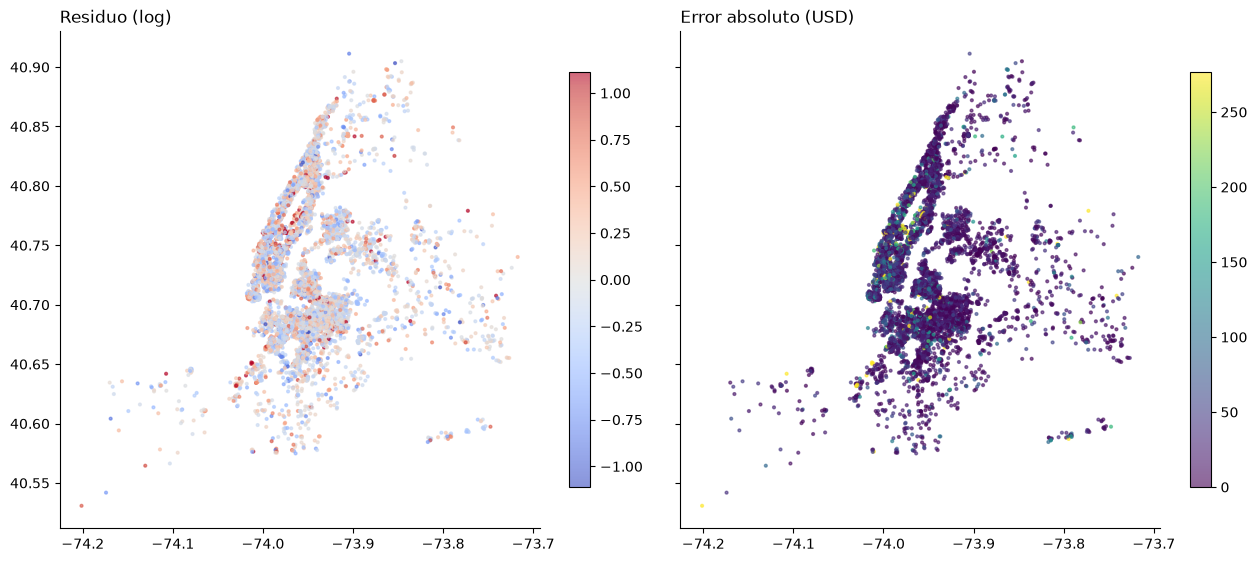

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
residuo = y_test - pred_test
for eje, (titulo, serie, mapa) in zip(ejes, [('Residuo (log)', residuo, 'coolwarm'),
                                             ('Error absoluto (USD)', test['error_abs_usd'], 'viridis')]):
    limite = np.percentile(np.abs(serie), 98)
    grafico = eje.scatter(test['longitude'], test['latitude'], c=serie, s=4, alpha=0.6, cmap=mapa,
                          vmin=-limite if mapa == 'coolwarm' else 0, vmax=limite)
    eje.set_title(titulo, loc='left')
    eje.set_aspect(1 / np.cos(np.radians(40.7)))
    eje.spines[['top', 'right']].set_visible(False)
    plt.colorbar(grafico, ax=eje, shrink=0.8)
plt.tight_layout()
plt.show()

In [12]:
# Sensibilidad a la regla de exclusion: metricas sin los precios por encima del P99 global del TRAIN
# (el corte no usa el test) frente a la regla de bloqueo ya aplicada en el dataset.
corte_p99 = train['price'].quantile(0.99)
sin_p99 = (test['price'] <= corte_p99).to_numpy()
filas = {'regla de bloqueo (la usada)': metricas(y_test, pred_test),
         f'sin P99 global (>{corte_p99:.0f} USD)': metricas(y_test[sin_p99], pred_test[sin_p99])}
display(pd.DataFrame(filas).T.round(4).assign(n=[len(test), int(sin_p99.sum())]))

,rmse_log_val,mae_log_val,r2_log_val,mae_usd_val,medae_usd_val,mape_val,n
regla de bloqueo (la usada),0.4298,0.3119,0.6350,50.2151,21.2734,0.3127,7384
sin P99 global (>794 USD),0.3949,0.2989,0.6465,39.3027,20.8763,0.3083,7303


#### Conclusiones:

- A rellenar tras ejecutar: segmentos con mayor **MAE** y **MAPE**, si quedan **manchas espaciales** en el mapa
  de residuos, qué tienen en común los 20 peores errores y cuánto cambian las métricas con la regla del P99.

## 7. INTERPRETACIÓN

Permutación en el test, PDP + ICE y SHAP nativo de CatBoost. Los tres anuncios que se explican por separado se
eligen con una regla fijada aquí, antes de mirar su explicación: el de error más cercano a la mediana, el anuncio
del 5 % más caro mejor predicho y el peor error de la sección 6.

In [13]:
grupos_bloque = {b: [c for c in cols if c in COLUMNAS] for b, cols in bloques.items()}
grupos_bloque = {b: c for b, c in grupos_bloque.items() if c}
grupos_variable = {c: [c] for c in COLUMNAS if c not in ('latitude', 'longitude')}
grupos_variable['latitude + longitude'] = ['latitude', 'longitude']

imp_bloques = importancia_permutacion(modelo_final, X_test, test[TARGET], grupos_bloque)
imp_variables = importancia_permutacion(modelo_final, X_test, test[TARGET], grupos_variable)

def resumen_importancia(tabla):
    return tabla.groupby('grupo')['aumento_rmse'].agg(['mean', 'std']).sort_values('mean', ascending=False)

display(resumen_importancia(imp_bloques).round(4))
display(resumen_importancia(imp_variables).head(15).round(4))

,mean,std
grupo,,
B0_producto,0.2977,0.0041
B1_ubicacion,0.1114,0.0019
B3_amenities_comunes,0.0477,0.0009
B2b_anfitrion,0.0454,0.0020
B2a_condiciones,0.0035,0.0004


,mean,std
grupo,,
property_type_grp,0.0533,0.0008
accommodates,0.0533,0.0022
room_type,0.0471,0.0014
latitude + longitude,0.0249,0.0014
bedrooms,0.0241,0.0010
neighbourhood,0.0124,0.0009
dist_centro_km,0.0091,0.0006
district,0.0085,0.0005
host_total_listings_count,0.0073,0.0008


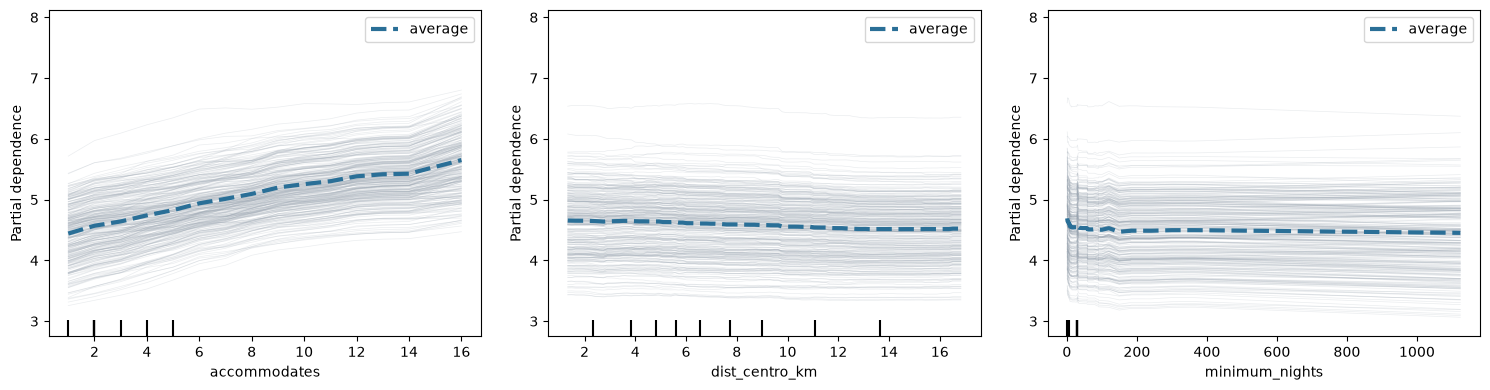

In [14]:
from sklearn.inspection import PartialDependenceDisplay

vars_pdp = ['accommodates', 'dist_centro_km', 'minimum_nights']
X_pdp = X_test.astype({v: 'float64' for v in vars_pdp})   # sklearn no admite enteros en PDP

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(modelo_final, X_pdp, vars_pdp,
                                        kind='both', subsample=300, random_state=SEMILLA, ax=ejes,
                                        ice_lines_kw={'color': COLOR_SECUNDARIO, 'alpha': 0.2},
                                        pd_line_kw={'color': COLOR_BASE, 'lw': 3})
plt.tight_layout()
plt.show()

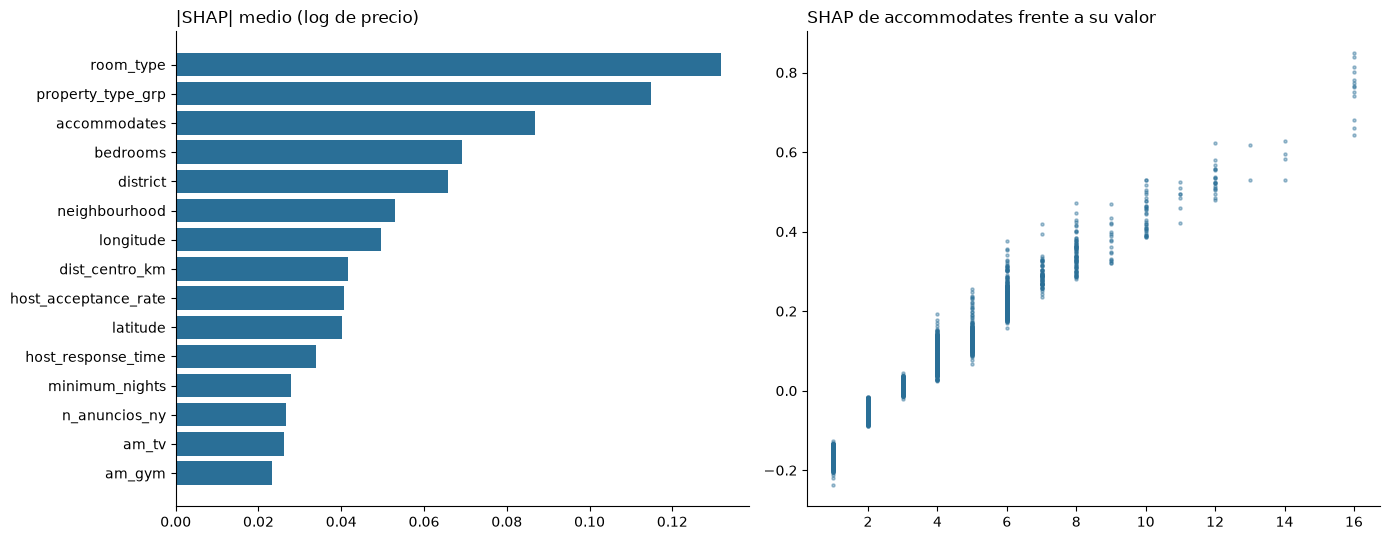

In [15]:
from catboost import Pool

def valores_shap(modelo, X):
    pool = Pool(modelo._preparar(X), cat_features=modelo.categoricas_)
    bruto = modelo.modelo_.get_feature_importance(pool, type='ShapValues')
    return bruto[:, :-1], bruto[:, -1][0]   # contribuciones por variable y valor base

shap_test, valor_base = valores_shap(modelo_final, X_test)
shap_medio = pd.Series(np.abs(shap_test).mean(axis=0), index=COLUMNAS).sort_values(ascending=False)
# Las contribuciones mas el valor base suman la prediccion: comprobacion de la implementacion
assert np.allclose(valor_base + shap_test.sum(axis=1), pred_test, atol=1e-3)

principales = shap_medio.head(15)[::-1]
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))
ejes[0].barh(principales.index, principales.values, color=COLOR_BASE)
ejes[0].set_title('|SHAP| medio (log de precio)', loc='left')
numericas = [c for c in shap_medio.index if pd.api.types.is_numeric_dtype(X_test[c]) and X_test[c].nunique() > 2][:1]
for c in numericas:
    ejes[1].scatter(X_test[c], shap_test[:, COLUMNAS.index(c)], s=5, alpha=0.4, color=COLOR_BASE)
    ejes[1].set_title(f'SHAP de {c} frente a su valor', loc='left')
for eje in ejes:
    eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
error_mediano = test['error_abs_usd'].median()
tipico = (test['error_abs_usd'] - error_mediano).abs().idxmin()
caros = test[test['price'] >= test['price'].quantile(0.95)]
caro_bien = (caros['error_abs_usd'] / caros['price']).idxmin()
peor = test['error_abs_usd'].idxmax()

for etiqueta, i in {'tipico': tipico, 'caro bien predicho': caro_bien, 'peor error': peor}.items():
    contribuciones = pd.Series(shap_test[test.index.get_loc(i)], index=COLUMNAS)
    principales = contribuciones.reindex(contribuciones.abs().sort_values(ascending=False).index).head(6)
    print(f"{etiqueta}: precio real {test.loc[i, 'price']:.0f} USD, predicho {test.loc[i, 'pred_usd']:.0f} USD "
          f"(base {np.exp(valor_base):.0f} USD)")
    display(pd.DataFrame({'valor': X_test.loc[i, principales.index], 'shap_log': principales}).round(3))

tipico: precio real 80 USD, predicho 101 USD (base 100 USD)


,valor,shap_log
property_type_grp,Entire apartment,0.132
room_type,Entire place,0.131
longitude,-73.92115,-0.064
neighbourhood,Bushwick,-0.060
district,Brooklyn,-0.055
host_acceptance_rate,NaN,0.044


caro bien predicho: precio real 425 USD, predicho 421 USD (base 100 USD)


,valor,shap_log
bedrooms,3.0,0.284
accommodates,6,0.243
room_type,Entire place,0.141
district,Manhattan,0.113
latitude,40.70496,-0.100
longitude,-74.00812,0.090


peor error: precio real 6500 USD, predicho 418 USD (base 100 USD)


,valor,shap_log
accommodates,7,0.327
bedrooms,3.0,0.280
room_type,Entire place,0.157
am_indoor_fireplace,True,0.107
latitude,40.68766,-0.104
property_type_grp,Entire apartment,0.081


#### Conclusiones:

- A rellenar tras ejecutar: orden de importancia en el test frente al de la CV (¿se mantiene?), forma de las
  curvas PDP de `accommodates`, `dist_centro_km` y `minimum_nights`, y lo que explica SHAP en los tres anuncios.
- Contraste con el lineal: dónde coinciden los coeficientes hedónicos con el SHAP medio y dónde aparecen no
  linealidades o interacciones.
- SHAP describe cómo usa las variables el **modelo**, no una relación causal con el precio.

## 8. USO DEL MODELO GUARDADO

Se carga todo desde disco y se predice un anuncio **en bruto** (filas de `listings.csv`). La cadena es
anuncio en bruto → preparador → modelo → `exp(ŷ)`.

**Aviso:** `n_anuncios_ny` y `reputacion_cartera` se calculan sobre las filas que se pasan (decisión del 09-26).
Para un anfitrión con varios anuncios hay que pasar su cartera completa en Nueva York.

In [18]:
from preparacion_datos import PreparadorListings, RUTA_PREPARADOR, cargar_listings_ny

preparador = PreparadorListings.cargar(RUTA_PREPARADOR)
modelo_cargado = joblib.load(MODELS_DIR / 'modelo_final.joblib')
guardado = joblib.load(MODELS_DIR / 'cuantiles.joblib')

brutos = cargar_listings_ny(DATA_DIR / 'listings.csv')
anfitrion = train.loc[train['n_anuncios_ny'].between(2, 3), COL_GRUPO].iloc[0]
cartera = brutos[brutos['host_id'] == anfitrion]

resultado = predecir_precio(cartera, preparador, modelo_cargado, guardado['cuantiles'], guardado['correccion_cqr'],
                            COLUMNAS)
real = cartera.set_index('listing_id')['price'].reindex(resultado['listing_id']).to_numpy()
display(resultado.assign(precio_real=real).round(1))

en_train = resultado[resultado['listing_id'].isin(train['listing_id'])]   # los excluidos del dataset no estan
en_memoria = modelo_final.predict(train.set_index('listing_id').loc[en_train['listing_id'], COLUMNAS])
assert np.allclose(np.exp(en_memoria), en_train['precio_mediano'], rtol=1e-6), 'El modelo cargado predice distinto'
print('El modelo guardado predice igual que el de memoria')

,listing_id,precio_mediano,precio_bajo,precio_alto,precio_real
0,39487508,129.4,71.8,279.2,119
1,43162879,54.4,35.0,92.0,44
2,43163345,54.8,35.4,91.3,44


El modelo guardado predice igual que el de memoria


In [19]:
ficha = ficha_modelo(HIPERPARAMETROS, COLUMNAS, {'media': METRICAS_CV, 'sd': METRICAS_CV_SD},
                     {k: float(v) for k, v in METRICAS_TEST.items()}, CORRECCION_CQR,
                     particion['md5']['train'], particion['md5']['test'])
guardar_ficha(ficha, MODELS_DIR / 'ficha_modelo.json')
print(json.dumps(ficha['versiones'], indent=1))

{
 "python": "3.13.14",
 "catboost": "1.2.10",
 "scikit-learn": "1.9.0",
 "pandas": "3.0.5"
}
